In [4]:
import numpy as np
samples = np.random.normal(0, 1, 100)
distributions = {
    1: (0, 1),
    2: (1, 2),
    3: (-1, 0.5),
    4: (2, 1.5),
    5: (0.5, 0.8),
    6: (-0.5, 1.2),
    7: (1.5, 0.7),
    8: (-2, 1.8),
    9: (0.2, 0.9),
    10: (3, 2.1)
}
def payoff(choice):
    mean = distributions[choice][0]
    sigma = distributions[choice][1]
    return np.random.normal(mean,sigma,1)

def value_update(V,payoff,alpha,choice):
    V[choice-1] = V[choice-1] + alpha*(payoff - V[choice-1])
    return V


In [5]:
def f(i):
    return 1/(i+1)
def greedy_session(epsilon,stepwise,steps,V = np.zeros(10)):
    for i in range(steps):
        e = np.random.uniform(0,1,1)
        if e < epsilon:
            a = np.random.randint(1,11,1)
        else:
            a = np.argmax(V)+1
        V = value_update(V,payoff(int(a)),stepwise(i),a)
    return V

C:\Users\Jiacheng Du\AppData\Local\Temp\ipykernel_12456\2554449593.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V = value_update(V, payoff(int(a)), stepwise(i), a)
C:\Users\Jiacheng Du\AppData\Local\Temp\ipykernel_12456\470536891.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V[choice-1] = V[choice-1] + alpha*(payoff - V[choice-1])


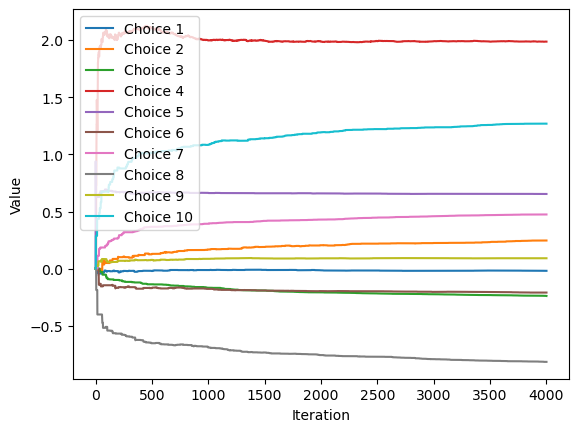

In [11]:
import matplotlib.pyplot as plt

def greedy_session_with_history(epsilon, stepwise, steps, V=np.zeros(10)):
    history = [V.copy()]
    for i in range(steps):
        e = np.random.uniform(0, 1, 1)
        if e < epsilon:
            a = np.random.randint(1, 11, 1)
        else:
            a = np.argmax(V) + 1
        V = value_update(V, payoff(int(a)), stepwise(i), a)
        history.append(V.copy())
    return history

# Run the simulation with history
hist = greedy_session_with_history(0.6, f, 4000)

# Plot for each choice with different colors
for i in range(10):
    plt.plot(range(len(hist)), [h[i] for h in hist], label=f'Choice {i+1}')

plt.xlabel('Iteration')
plt.ylabel('Value')
plt.legend()
plt.show()

In [6]:
greedy_session(0.1,f,100000)

C:\Users\Jiacheng Du\AppData\Local\Temp\ipykernel_12456\454966475.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V = value_update(V,payoff(int(a)),stepwise(i),a)
C:\Users\Jiacheng Du\AppData\Local\Temp\ipykernel_12456\470536891.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V[choice-1] = V[choice-1] + alpha*(payoff - V[choice-1])


array([ 0.04039687,  0.9964757 , -0.07265741,  0.15639449,  0.0388068 ,
       -0.0235296 ,  0.17490589, -0.20486723,  0.00128397,  0.19974425])

In [34]:
V = np.zeros(10)
lis = []
for i in range(1000):
    lis.append(payoff(1))
np.mean(lis)


np.float64(0.03662216062645524)

@ try except do while


In [3]:
def monte_carlo_pi(num_samples):
    inside = 0
    for _ in range(num_samples):
        x = np.random.uniform(-1, 1)
        y = np.random.uniform(-1, 1)
        if x**2 + y**2 <= 1:
            inside += 1
    return 4 * inside / num_samples

print(monte_carlo_pi(10000))

3.1524


Estimated pi: 3.141640879031118


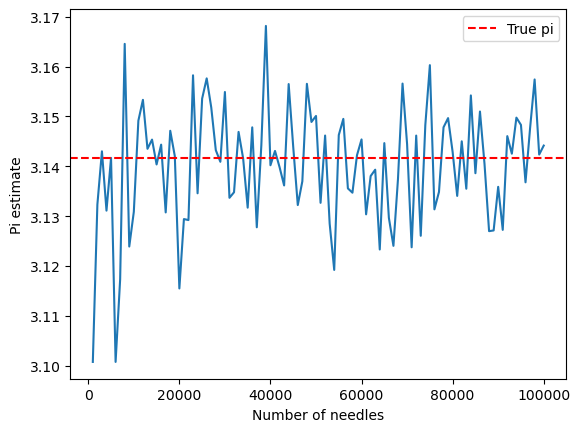

In [4]:
import matplotlib.pyplot as plt

# More complex Monte Carlo: Estimating the value of pi using Buffon's needle problem
def buffon_needle_pi(num_needles, needle_length=1, line_spacing=1):
    inside = 0
    for _ in range(num_needles):
        # Random position and angle
        x = np.random.uniform(0, line_spacing / 2)
        theta = np.random.uniform(0, np.pi / 2)
        # Check if needle crosses a line
        if x <= (needle_length / 2) * np.sin(theta):
            inside += 1
    return (2 * needle_length * num_needles) / (line_spacing * inside)

# Run simulation
pi_estimate = buffon_needle_pi(100000)
print(f"Estimated pi: {pi_estimate}")

# Optional: Plot convergence
estimates = []
for n in range(1000, 100001, 1000):
    estimates.append(buffon_needle_pi(n))
plt.plot(range(1000, 100001, 1000), estimates)
plt.axhline(y=np.pi, color='r', linestyle='--', label='True pi')
plt.xlabel('Number of needles')
plt.ylabel('Pi estimate')
plt.legend()
plt.show()

In [5]:
import requests
from bs4 import BeautifulSoup
import os

# Function to download a file from a URL
def download_file(url, folder):
    response = requests.get(url)
    filename = os.path.join(folder, url.split('/')[-1])
    
    with open(filename, 'wb') as f:
        f.write(response.content)
    
    print(f'Downloaded: {filename}')

# Main function to crawl the website
def crawl_and_download(base_url, folder):
    # Create folder if it doesn't exist
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    # Get the HTML content of the page
    response = requests.get(base_url)
    soup = BeautifulSoup(response.text, 'html.parser')

    # Find all slide links (assuming they are in <a> tags)
    for link in soup.find_all('a'):
        href = link.get('href')
        # Check if the link ends with a slide extension (e.g., .pdf, .pptx, etc.)
        if href and (href.endswith('.pdf') or href.endswith('.pptx')):
            download_file(href, folder)

# Example usage
if __name__ == '__main__':
    website_url = 'https://davidstarsilver.wordpress.com/teaching/'  # Replace with the actual URL
    download_folder = 'D:/CS'
    crawl_and_download(website_url, download_folder)


Downloaded: D:/CS\intro_rl.pdf
Downloaded: D:/CS\lecture-2-mdp.pdf
Downloaded: D:/CS\lecture-3-planning-by-dynamic-programming-.pdf
Downloaded: D:/CS\lecture-4-model-free-prediction-.pdf
Downloaded: D:/CS\lecture-5-model-free-control-.pdf
Downloaded: D:/CS\lecture-6-value-function-approximation-.pdf
Downloaded: D:/CS\lecture-7-policy-gradient-methods.pdf
Downloaded: D:/CS\lecture-8-integrating-learning-and-planning.pdf
Downloaded: D:/CS\lecture-9-exploration-and-exploitation.pdf
Downloaded: D:/CS\lecture-10-case-study-rl-in-classic-games.pdf
Downloaded: D:/CS\easy21-assignment.pdf
Downloaded: D:/CS\previous-rl-exam-questions-.pdf
Downloaded: D:/CS\previous-rl-exam-answers.pdf


In [3]:
import numpy as np
bar = 0
for _ in range(1000):
    bar += (1/(_+1))*(np.random.normal(1,1,1) - bar)
bar

array([1.01772067])